In [202]:
import pandas as pd
df = pd.read_csv('players_21.csv')  # apna filename daal
print(df.shape)
print(df.columns.tolist())

(18944, 106)
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club_name', 'league_name', 'league_rank', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions',

In [203]:
df = df[~df['player_positions'].str.contains('GK', na=False)].copy()


In [204]:
keep_cols = [
    # Identity
    'short_name', 'age', 'nationality', 'club_name',
    'overall', 'potential', 'value_eur', 'wage_eur',
    'player_positions', 'international_reputation',
    
    # Core FIFA attributes (yahi features banenge)
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    
    # Granular attributes (deeper features)
    'attacking_finishing', 'attacking_short_passing',
    'attacking_heading_accuracy', 'attacking_crossing',
    'skill_dribbling', 'skill_ball_control',
    'skill_long_passing', 'skill_curve',
    'movement_acceleration', 'movement_sprint_speed',
    'movement_agility', 'movement_reactions', 'movement_balance',
    'power_stamina', 'power_strength', 'power_shot_power',
    'mentality_vision', 'mentality_composure',
    'mentality_positioning', 'mentality_aggression',
    'mentality_interceptions', 'mentality_penalties',
    'defending_marking', 'defending_standing_tackle',
    'defending_sliding_tackle',
    'weak_foot', 'skill_moves'
]
df = df[keep_cols].copy()


In [205]:
df = df.dropna(subset=['pace','shooting','passing', 'dribbling','defending','physic'])

print(f"Players after cleaning: {df.shape[0]}")
print(df.head(3))

Players after cleaning: 16860
          short_name  age nationality          club_name  overall  potential  \
0           L. Messi   33   Argentina       FC Barcelona       93         93   
1  Cristiano Ronaldo   35    Portugal           Juventus       92         92   
3     R. Lewandowski   31      Poland  FC Bayern München       91         91   

   value_eur  wage_eur player_positions  international_reputation  ...  \
0   67500000    560000       RW, ST, CF                         5  ...   
1   46000000    220000           ST, LW                         5  ...   
3   80000000    240000               ST                         4  ...   

   mentality_composure  mentality_positioning  mentality_aggression  \
0                   96                     93                    44   
1                   95                     95                    63   
3                   88                     94                    81   

   mentality_interceptions  mentality_penalties  defending_marking 

In [206]:
def get_pos_category(pos_str):
    if pd.isna(pos_str):
        return 'Unknown'
    
    primary = pos_str.split(',')[0].strip()
    
    if primary in ['ST','CF','LW','RW','LF','RF']:
        return 'Attacker'
    elif primary in ['CAM','CM','CDM','LM','RM','LAM','RAM','LCM','RCM']:
        return 'Midfielder'
    elif primary in ['LB','RB','CB','LWB','RWB','LCB','RCB']:
        return 'Defender'
    return 'Unknown'

df['pos_category'] = df['player_positions'].apply(get_pos_category)

In [207]:
print("Position distribution:")
print(df['pos_category'].value_counts())
print(f"\nUnknown positions: {(df['pos_category']=='Unknown').sum()}")

Position distribution:
pos_category
Midfielder    7037
Defender      6205
Attacker      3618
Name: count, dtype: int64

Unknown positions: 0


In [208]:
# Defending columns — attackers ke liye 0 make sense karta hai
defending_cols = ['defending_marking', 'defending_standing_tackle',  'defending_sliding_tackle', 'mentality_interceptions']

#Similary attacking columnd - defender ke liye zero sense banayenge
attacking_cols = ['attacking_finishing', 'mentality_positioning']

for col in defending_cols + attacking_cols:
    df[col] = df[col].fillna(0)


In [209]:
remaining_cols = ['movement_reactions', 'mentality_vision', 
                  'mentality_composure', 'power_stamina',
                  'power_strength', 'movement_agility',
                  'skill_ball_control', 'attacking_short_passing',
                  'skill_long_passing', 'movement_acceleration']

for col in remaining_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\nNaN remaining: {df.isnull().sum().sum()}")



NaN remaining: 195


**MATCH IMPACT SCORE**

Initaially sabka match impact score zero set karenge then according to division match imact score set karenge

ATTACKERS
 Vision + composure + reactions intentionally high
 Pace intentionally low (challenging FIFA's bias)

 MIDFIELDERS 
Vision sabse important
Pace almost irrelevant

 DEFENDERS
Composure + reactions underrated by FIFA
 Pure pace very low weight


In [210]:
attacker_mask  = df['pos_category'] == 'Attacker'
midfielder_mask = df['pos_category'] == 'Midfielder'
defender_mask  = df['pos_category'] == 'Defender'

df['match_impact'] = 0.0


In [211]:
df.loc[attacker_mask, 'match_impact'] = (
    df['attacking_finishing']    * 0.22 +
    df['mentality_positioning']  * 0.15 +
    df['movement_reactions']     * 0.14 +
    df['mentality_composure']    * 0.13 +
    df['mentality_vision']       * 0.11 +
    df['skill_ball_control']     * 0.09 +
    df['movement_agility']       * 0.08 +
    df['pace']                   * 0.05 +  # deliberately low
    df['power_shot_power']       * 0.03
)

In [212]:
df.loc[midfielder_mask, 'match_impact'] = (
    df['mentality_vision']          * 0.22 +
    df['attacking_short_passing']   * 0.18 +
    df['mentality_composure']       * 0.15 +
    df['movement_reactions']        * 0.12 +
    df['skill_ball_control']        * 0.11 +
    df['power_stamina']             * 0.10 +
    df['skill_long_passing']        * 0.08 +
    df['pace']                      * 0.02 +  # almost irrelevant
    df['movement_agility']          * 0.02
)


In [213]:
df.loc[defender_mask, 'match_impact'] = (
    df['defending_standing_tackle'] * 0.20 +
    df['mentality_interceptions']   * 0.18 +
    df['defending_marking']         * 0.15 +
    df['movement_reactions']        * 0.13 +
    df['power_strength']            * 0.11 +
    df['mentality_composure']       * 0.11 +
    df['mentality_aggression']      * 0.07 +
    df['pace']                      * 0.03 +
    df['defending_sliding_tackle']  * 0.02
)

In [214]:
df.loc[df['pos_category']=='Unknown', 'match_impact'] = df['overall'] * 0.85

df['match_impact'] = (
    (df['match_impact'] - df['match_impact'].min()) /
    (df['match_impact'].max() - df['match_impact'].min()) * 100
).round(2)


In [215]:
print("\n=== Match Impact Stats ===")
print(df['match_impact'].describe().round(2))

print("\n=== Top 10 Most Impactful Players ===")
top10 = df.nlargest(10, 'match_impact')[
    ['short_name','pos_category','overall','match_impact']
]
print(top10.to_string())




=== Match Impact Stats ===
count    16860.00
mean        44.99
std         13.93
min          0.00
25%         34.79
50%         44.37
75%         54.46
max        100.00
Name: match_impact, dtype: float64

=== Top 10 Most Impactful Players ===
           short_name pos_category  overall  match_impact
0            L. Messi     Attacker       93        100.00
1   Cristiano Ronaldo     Attacker       92         97.73
5        K. De Bruyne   Midfielder       91         96.70
4           Neymar Jr     Attacker       91         94.02
13          S. Agüero     Attacker       89         93.72
11           M. Salah     Attacker       90         93.57
10            S. Mané     Attacker       90         93.12
38          L. Modrić   Midfielder       87         92.59
6           K. Mbappé     Attacker       90         92.37
3      R. Lewandowski     Attacker       91         91.49


In [216]:
print("\n=== Average Impact by Position ===")
print(df.groupby('pos_category')['match_impact'].mean().round(2))



=== Average Impact by Position ===
pos_category
Attacker      50.81
Defender      34.60
Midfielder    51.16
Name: match_impact, dtype: float64


In [217]:
df.to_csv('fifa_cleaned.csv', index=False)
print("\nfifa_cleaned.csv saved!")


fifa_cleaned.csv saved!


In [218]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [219]:
df = pd.read_csv('fifa_cleaned.csv')

# Yeh features model ko denge
feature_cols = [
    'age', 'overall', 'potential',
    'pace', 'shooting', 'passing', 
    'dribbling', 'defending', 'physic',
    'attacking_finishing', 'attacking_short_passing',
    'attacking_crossing', 'attacking_heading_accuracy',
    'skill_dribbling', 'skill_ball_control',
    'skill_long_passing', 'skill_curve',
    'movement_acceleration', 'movement_sprint_speed',
    'movement_agility', 'movement_reactions', 'movement_balance',
    'power_stamina', 'power_strength', 'power_shot_power',
    'mentality_vision', 'mentality_composure',
    'mentality_positioning', 'mentality_aggression',
    'mentality_interceptions', 'mentality_penalties',
    'defending_marking', 'defending_standing_tackle',
    'defending_sliding_tackle',
    'weak_foot', 'skill_moves',
    'international_reputation'
]

In [220]:
pos_map = {'Attacker': 2, 'Midfielder': 1, 'Defender': 0, 'Unknown': -1}
df['pos_encoded'] = df['pos_category'].map(pos_map)
feature_cols.append('pos_encoded')


In [221]:
X = df[feature_cols]
y = df['match_impact']

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")
print(f"Target range: {y.min():.1f} to {y.max():.1f}")

Features: 38
Samples:  16860
Target range: 0.0 to 100.0


In [222]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42     
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")



Train size: 13488
Test size:  3372


In [223]:
model = XGBRegressor(
    n_estimators=300,       # 300 trees banao
    learning_rate=0.05,     # har tree ka contribution chhota rakho
    max_depth=5,            # tree ki depth — overfitting control
    subsample=0.8,          # har tree ke liye 80% data use karo
    colsample_bytree=0.8,   # har tree ke liye 80% features use karo
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.0,         # L2 regularization
    random_state=42,
    verbosity=0
)

In [224]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("\nModel trained!")



Model trained!


In [225]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [226]:
print(f"\n=== Model Performance ===")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"R² Score:                  {r2:.4f}")
print(f"\nMeaning: Model ki prediction average")
print(f"{mae:.1f} points door hoti hai actual se (0-100 scale)")


=== Model Performance ===
MAE (Mean Absolute Error): 0.81
R² Score:                  0.9938

Meaning: Model ki prediction average
0.8 points door hoti hai actual se (0-100 scale)


In [227]:
BG    = '#0f0f1a'
CARD  = '#1a1a2e'
TEAL  = '#00e5cc'
GOLD  = '#f0c040'
CORAL = '#ff6b6b'
WHITE = '#e8e8f0'
PURPLE= '#b388ff'

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

def style_ax(ax, title):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors=WHITE, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')


<Figure size 1800x1200 with 0 Axes>

ACTUAL VS PREDICTED

In [228]:
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.3, s=8, color=TEAL)
ax1.plot([0,100],[0,100], color=GOLD, lw=2, linestyle='--', label='Perfect prediction')
ax1.set_xlabel('Actual Impact', color=WHITE, fontsize=9)
ax1.set_ylabel('Predicted Impact', color=WHITE, fontsize=9)
ax1.legend(fontsize=8, labelcolor=WHITE, facecolor=CARD, edgecolor='none')
style_ax(ax1, f'Actual vs Predicted (R²={r2:.3f})')


ERROR DISTRIBUTION

In [229]:
ax2 = fig.add_subplot(gs[0, 1])
errors = y_pred - y_test.values
ax2.hist(errors, bins=50, color=PURPLE, alpha=0.85, edgecolor='none')
ax2.axvline(0, color=GOLD, lw=2, linestyle='--')
ax2.axvline(mae, color=CORAL, lw=1.5, linestyle=':', label=f'MAE={mae:.2f}')
ax2.axvline(-mae, color=CORAL, lw=1.5, linestyle=':')
ax2.set_xlabel('Prediction Error', color=WHITE, fontsize=9)
ax2.legend(fontsize=8, labelcolor=WHITE, facecolor=CARD, edgecolor='none')
style_ax(ax2, 'Error Distribution')

In [230]:
ax3 = fig.add_subplot(gs[0, 2])
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

colors = [CORAL if 'pace' in f or 'sprint' in f or 'acceleration' in f 
          else TEAL for f in importance_df['feature']]
ax3.barh(importance_df['feature'], importance_df['importance'], 
         color=colors, alpha=0.85)
ax3.set_xlabel('Importance', color=WHITE, fontsize=9)
style_ax(ax3, 'Top 15 Features (Red = pace-related)')


In [231]:
ax4 = fig.add_subplot(gs[1, 0])
scatter = ax4.scatter(df['overall'], df['match_impact'],
                      c=df['mentality_vision'], cmap='plasma',
                      alpha=0.3, s=8)
plt.colorbar(scatter, ax=ax4, label='Vision').ax.yaxis.label.set_color(WHITE)
corr_val = df['overall'].corr(df['match_impact'])
ax4.text(0.05, 0.92, f'Correlation: {corr_val:.3f}', 
         transform=ax4.transAxes, color=GOLD, fontsize=10, fontweight='bold')
ax4.set_xlabel('FIFA Overall Rating', color=WHITE, fontsize=9)
ax4.set_ylabel('Match Impact Score', color=WHITE, fontsize=9)
style_ax(ax4, 'FIFA Overall vs Real Impact (color=Vision)')


<Figure size 640x480 with 0 Axes>

In [232]:
ax5 = fig.add_subplot(gs[1, 1])
pace_corr = df['pace'].corr(df['match_impact'])
vision_corr = df['mentality_vision'].corr(df['match_impact'])
composure_corr = df['mentality_composure'].corr(df['match_impact'])

attrs  = ['pace', 'vision', 'composure', 'reactions', 
          'finishing', 'stamina', 'strength']
corrs  = [
    df['pace'].corr(df['match_impact']),
    df['mentality_vision'].corr(df['match_impact']),
    df['mentality_composure'].corr(df['match_impact']),
    df['movement_reactions'].corr(df['match_impact']),
    df['attacking_finishing'].corr(df['match_impact']),
    df['power_stamina'].corr(df['match_impact']),
    df['power_strength'].corr(df['match_impact'])
]
bar_colors = [CORAL if a == 'pace' else TEAL for a in attrs]
bars = ax5.barh(attrs, corrs, color=bar_colors, alpha=0.85)
ax5.axvline(0, color=WHITE, lw=0.5)
style_ax(ax5, 'Attribute Correlation with Impact')
ax5.set_xlabel('Correlation', color=WHITE, fontsize=9)

Text(0.5, 0, 'Correlation')

In [233]:
ax6 = fig.add_subplot(gs[1, 2])
df['impact_vs_overall'] = df['match_impact'] - df['overall']
overrated   = df.nsmallest(8, 'impact_vs_overall')[['short_name','impact_vs_overall']]
underrated  = df.nlargest(8, 'impact_vs_overall')[['short_name','impact_vs_overall']]

combined = pd.concat([overrated, underrated]).sort_values('impact_vs_overall')
bar_cols = [CORAL if v < 0 else TEAL for v in combined['impact_vs_overall']]
ax6.barh(combined['short_name'], combined['impact_vs_overall'], 
         color=bar_cols, alpha=0.85)
ax6.axvline(0, color=WHITE, lw=1)
style_ax(ax6, 'Overrated (red) vs Underrated (teal)')
ax6.set_xlabel('Impact - Overall', color=WHITE, fontsize=9)

fig.suptitle(
    'FIFA Ratings Lie — XGBoost Se Pakdo\n'
    '"Does EA Sports Actually Know What Makes a Player Impactful?"',
    color=WHITE, fontsize=14, fontweight='bold', y=0.98
)

plt.savefig('xgboost_results.png', dpi=150, 
            bbox_inches='tight', facecolor=BG)
print("\nxgboost_results.png saved!")


xgboost_results.png saved!


<Figure size 640x480 with 0 Axes>

In [234]:
print("\n=== Most OVERRATED Players (High Overall, Low Impact) ===")
df['gap'] = df['match_impact'] - df['overall']
print(df.nsmallest(5, 'gap')[
    ['short_name','pos_category','overall','match_impact','gap']
].to_string())

print("\n=== Most UNDERRATED Players (Low Overall, High Impact) ===")
print(df.nlargest(5, 'gap')[
    ['short_name','pos_category','overall','match_impact','gap']
].to_string())


=== Most OVERRATED Players (High Overall, Low Impact) ===
         short_name pos_category  overall  match_impact    gap
16816    L. Twamley     Defender       48          0.00 -48.00
16410  D. Jovanović     Defender       52          4.35 -47.65
16273   M. Dilmurat     Defender       53          6.55 -46.45
16051  B. Verkerken     Defender       54          8.43 -45.57
10194       J. Ward     Defender       64         18.75 -45.25

=== Most UNDERRATED Players (Low Overall, High Impact) ===
           short_name pos_category  overall  match_impact   gap
0            L. Messi     Attacker       93        100.00  7.00
1   Cristiano Ronaldo     Attacker       92         97.73  5.73
4        K. De Bruyne   Midfielder       91         96.70  5.70
30          L. Modrić   Midfielder       87         92.59  5.59
79         C. Eriksen   Midfielder       85         90.56  5.56


In [235]:

feature_cols_fixed = [f for f in feature_cols 
                      if f not in ['overall', 'potential']]

X_fixed = df[feature_cols_fixed]
y_fixed = df['match_impact']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_fixed, y_fixed, test_size=0.2, random_state=42
)

model2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

model2.fit(X_train2, y_train2,
           eval_set=[(X_test2, y_test2)],
           verbose=False)

y_pred2   = model2.predict(X_test2)
mae2      = mean_absolute_error(y_test2, y_pred2)
r2_2      = r2_score(y_test2, y_pred2)

print(f"R² (without overall): {r2_2:.4f}")
print(f"MAE:                  {mae2:.2f}")

# Position-wise percentile rank banao
# Har player ko uske position group mein rank karo
df['predicted_impact'] = model2.predict(X_fixed)

df['impact_percentile'] = df.groupby('pos_category')['predicted_impact']\
                            .rank(pct=True) * 100

df['overall_percentile'] = df.groupby('pos_category')['overall']\
                             .rank(pct=True) * 100

# Gap = predicted percentile - overall percentile
# Positive = underrated (impact rank > overall rank)
# Negative = overrated  (overall rank > impact rank)
df['percentile_gap'] = (df['impact_percentile'] - 
                        df['overall_percentile']).round(2)

print("\n=== OVERRATED (FIFA overestimates them) ===")
print(df.nsmallest(8, 'percentile_gap')[
    ['short_name','pos_category','overall',
     'predicted_impact','percentile_gap']
].to_string())

print("\n=== UNDERRATED (FIFA underestimates them) ===")
print(df.nlargest(8, 'percentile_gap')[
    ['short_name','pos_category','overall',
     'predicted_impact','percentile_gap']
].to_string())

print("\n=== PACE vs VISION — The Key Insight ===")
print(f"Pace correlation with impact:    "
      f"{df['pace'].corr(df['match_impact']):.3f}")
print(f"Vision correlation with impact:  "
      f"{df['mentality_vision'].corr(df['match_impact']):.3f}")
print(f"Composure correlation with impact: "
      f"{df['mentality_composure'].corr(df['match_impact']):.3f}")

R² (without overall): 0.9944
MAE:                  0.77

=== OVERRATED (FIFA overestimates them) ===
       short_name pos_category  overall  predicted_impact  percentile_gap
4221         Witi     Defender       70         26.732096          -52.81
3996   F. Viáfara     Defender       71         28.484688          -51.95
5024  E. Saavedra     Defender       69         26.116899          -49.22
5136   C. Cándido     Defender       69         26.521465          -48.12
3748      Kalindi     Defender       71         29.832533          -47.12
3589     K. Anzai     Defender       71         29.846815          -47.05
5271    I. Sackey   Midfielder       69         42.153667          -44.59
3893    W. Lautoa   Midfielder       71         45.698666          -44.05

=== UNDERRATED (FIFA underestimates them) ===
           short_name pos_category  overall  predicted_impact  percentile_gap
14295      R. Sánchez   Midfielder       59         52.949890           39.36
12741   M. Villarroel   Midfie

=== FAMOUS OVERRATED PLAYERS (Overall 75+) ===
          short_name pos_category  overall  predicted_impact  percentile_gap
592   R. Di Leonardo     Defender       79         43.813744          -68.55
420  Maikel Catarino     Defender       80         45.469234          -68.47
486        Odriozola     Defender       79         44.813709          -63.71
446     Adama Traoré     Attacker       79         64.344582          -63.27
330     M. Arambarri   Midfielder       80         65.263977          -61.86
591       E. Guichón     Defender       79         45.441616          -61.13
566        Mário Rui     Defender       79         45.775894          -58.87
272    Javi Martínez   Midfielder       81         67.068535          -58.47
639          E. Dier   Midfielder       78         62.083836          -57.28
279      J. Cuadrado     Defender       81         48.472172          -57.26

=== FAMOUS UNDERRATED PLAYERS (Overall 75+) ===
        short_name pos_category  overall  predicted_impac

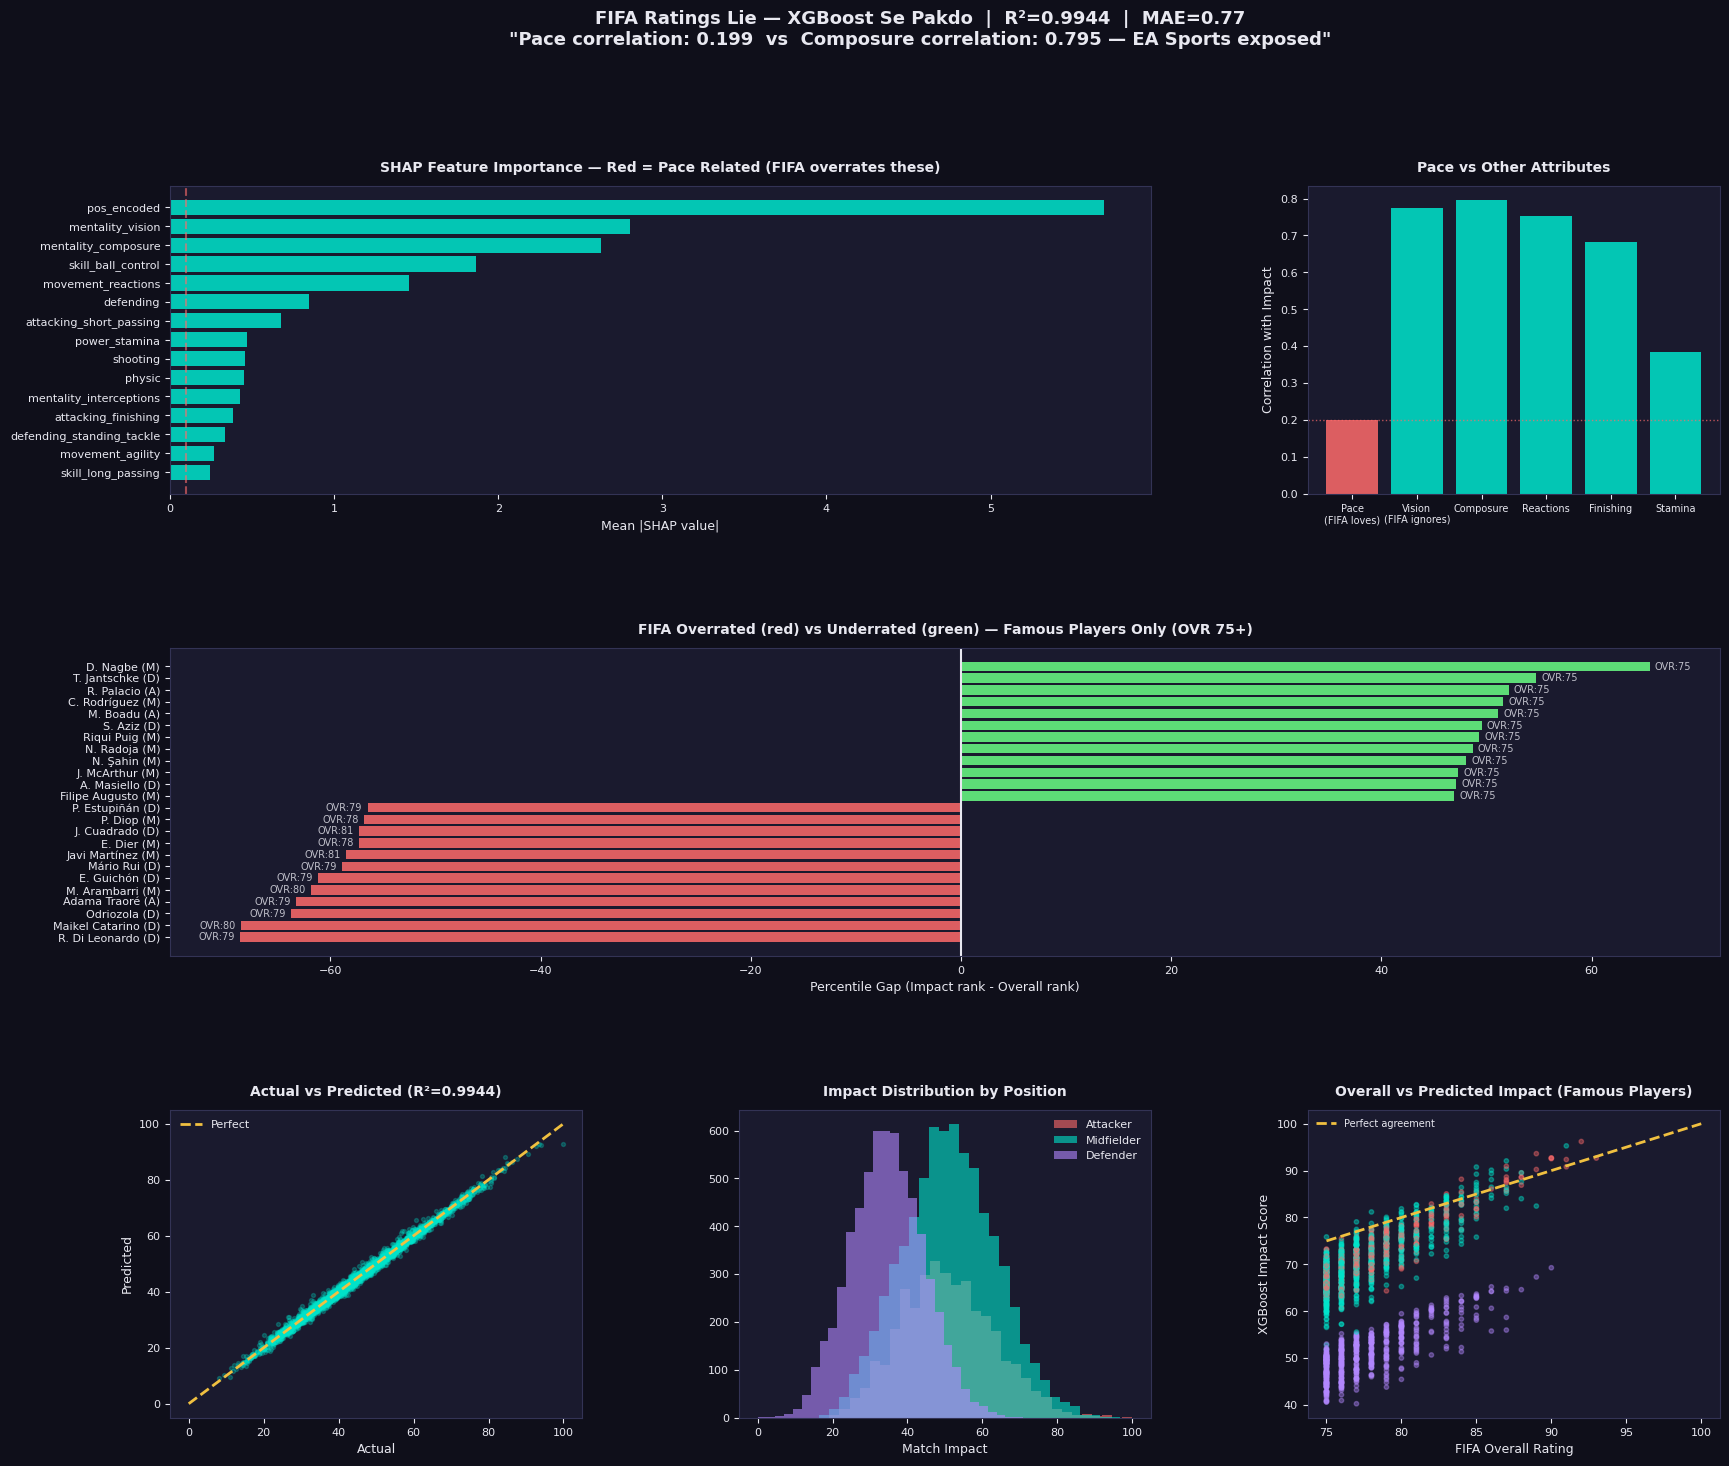

In [236]:
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================
# FAMOUS PLAYERS FILTER
# ============================================
# Sirf wo players jo somewhat known hain
df_famous = df[df['overall'] >= 75].copy()
df_famous['predicted_impact'] = model2.predict(
    df_famous[feature_cols_fixed]
)

df_famous['impact_percentile'] = df_famous.groupby('pos_category')['predicted_impact']\
                                           .rank(pct=True) * 100
df_famous['overall_percentile'] = df_famous.groupby('pos_category')['overall']\
                                            .rank(pct=True) * 100
df_famous['percentile_gap'] = (df_famous['impact_percentile'] - 
                                df_famous['overall_percentile']).round(2)

print("=== FAMOUS OVERRATED PLAYERS (Overall 75+) ===")
overrated = df_famous.nsmallest(10, 'percentile_gap')[
    ['short_name','pos_category','overall',
     'predicted_impact','percentile_gap']
]
print(overrated.to_string())

print("\n=== FAMOUS UNDERRATED PLAYERS (Overall 75+) ===")
underrated = df_famous.nlargest(10, 'percentile_gap')[
    ['short_name','pos_category','overall',
     'predicted_impact','percentile_gap']
]
print(underrated.to_string())

# ============================================
# SHAP VALUES — Model ke andar jhhaanko
# ============================================
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(model2)

# Sample 500 players for SHAP (fast computation)
sample = df[feature_cols_fixed].sample(500, random_state=42)
shap_values = explainer.shap_values(sample)

shap_df = pd.DataFrame(shap_values, columns=feature_cols_fixed)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

print("\nTop 10 features by SHAP importance:")
print(mean_shap.head(10).round(4))

# ============================================
# FINAL DASHBOARD
# ============================================
BG    = '#0f0f1a'
CARD  = '#1a1a2e'
TEAL  = '#00e5cc'
GOLD  = '#f0c040'
CORAL = '#ff6b6b'
WHITE = '#e8e8f0'
PURPLE= '#b388ff'
GREEN = '#69ff85'

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

def style_ax(ax, title):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=10,
                 fontweight='bold', pad=10)
    ax.tick_params(colors=WHITE, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

# ── Plot 1: SHAP Feature Importance ──
ax1 = fig.add_subplot(gs[0, :2])
top_shap = mean_shap.head(15).sort_values()
pace_related = ['pace','movement_sprint_speed','movement_acceleration']
colors = [CORAL if f in pace_related else TEAL for f in top_shap.index]
ax1.barh(top_shap.index, top_shap.values, color=colors, alpha=0.85)
ax1.set_xlabel('Mean |SHAP value|', color=WHITE, fontsize=9)
ax1.axvline(mean_shap['pace'], color=CORAL, 
            lw=1.5, linestyle='--', alpha=0.6)
style_ax(ax1, 'SHAP Feature Importance — Red = Pace Related (FIFA overrates these)')

# ── Plot 2: Pace vs Vision — The Proof ──
ax2 = fig.add_subplot(gs[0, 2])
key_attrs  = ['pace', 'mentality_vision', 
              'mentality_composure', 'movement_reactions',
              'attacking_finishing', 'power_stamina']
key_labels = ['Pace\n(FIFA loves)', 'Vision\n(FIFA ignores)', 
              'Composure', 'Reactions', 'Finishing', 'Stamina']
key_corrs  = [df[c].corr(df['match_impact']) for c in key_attrs]
bar_colors = [CORAL if c == 'pace' else TEAL 
              for c in key_attrs]
ax2.bar(key_labels, key_corrs, color=bar_colors, alpha=0.85)
ax2.axhline(0.2, color=CORAL, lw=1, linestyle=':', alpha=0.7)
ax2.set_ylabel('Correlation with Impact', color=WHITE, fontsize=9)
style_ax(ax2, 'Pace vs Other Attributes')
ax2.tick_params(axis='x', labelsize=7)

# ── Plot 3: Overrated Players ──
ax3 = fig.add_subplot(gs[1, :])
over_plot  = df_famous.nsmallest(12, 'percentile_gap')
under_plot = df_famous.nlargest(12, 'percentile_gap')
combined   = pd.concat([over_plot, under_plot])\
               .sort_values('percentile_gap')

bar_cols = [CORAL if v < 0 else GREEN 
            for v in combined['percentile_gap']]
bars = ax3.barh(
    combined['short_name'] + ' (' + combined['pos_category'].str[0] + ')',
    combined['percentile_gap'],
    color=bar_cols, alpha=0.85
)
ax3.axvline(0, color=WHITE, lw=1.5)
ax3.set_xlabel('Percentile Gap (Impact rank - Overall rank)', 
               color=WHITE, fontsize=9)

# Annotations
for bar, (_, row) in zip(bars, combined.iterrows()):
    label = f"OVR:{int(row['overall'])}"
    x_pos = bar.get_width()
    ha = 'left' if x_pos >= 0 else 'right'
    offset = 0.5 if x_pos >= 0 else -0.5
    ax3.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
             label, va='center', ha=ha,
             color=WHITE, fontsize=7, alpha=0.8)

style_ax(ax3, 'FIFA Overrated (red) vs Underrated (green) — Famous Players Only (OVR 75+)')

# ── Plot 4: Actual vs Predicted ──
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(y_test2, y_pred2, alpha=0.25, s=8, color=TEAL)
ax4.plot([0,100],[0,100], color=GOLD, lw=2, 
         linestyle='--', label='Perfect')
ax4.set_xlabel('Actual', color=WHITE, fontsize=9)
ax4.set_ylabel('Predicted', color=WHITE, fontsize=9)
ax4.legend(fontsize=8, labelcolor=WHITE, 
           facecolor=CARD, edgecolor='none')
style_ax(ax4, f'Actual vs Predicted (R²={r2_2:.4f})')

# ── Plot 5: Position-wise Impact Distribution ──
ax5 = fig.add_subplot(gs[2, 1])
pos_colors = {'Attacker': CORAL, 'Midfielder': TEAL, 'Defender': PURPLE}
for pos, color in pos_colors.items():
    subset = df[df['pos_category'] == pos]['match_impact']
    ax5.hist(subset, bins=30, alpha=0.6, 
             color=color, label=pos, edgecolor='none')
ax5.set_xlabel('Match Impact', color=WHITE, fontsize=9)
ax5.legend(fontsize=8, labelcolor=WHITE, 
           facecolor=CARD, edgecolor='none')
style_ax(ax5, 'Impact Distribution by Position')

# ── Plot 6: Overall vs Predicted Impact ──
ax6 = fig.add_subplot(gs[2, 2])
pos_colors_list = [pos_colors.get(p, WHITE) 
                   for p in df_famous['pos_category']]
ax6.scatter(df_famous['overall'], 
            df_famous['predicted_impact'],
            c=[{'Attacker': '#ff6b6b', 
                'Midfielder': '#00e5cc', 
                'Defender': '#b388ff'}.get(p, WHITE) 
               for p in df_famous['pos_category']],
            alpha=0.4, s=10)
ax6.plot([75,100],[75,100], color=GOLD, 
         lw=2, linestyle='--', label='Perfect agreement')
ax6.set_xlabel('FIFA Overall Rating', color=WHITE, fontsize=9)
ax6.set_ylabel('XGBoost Impact Score', color=WHITE, fontsize=9)
ax6.legend(fontsize=7, labelcolor=WHITE, 
           facecolor=CARD, edgecolor='none')
style_ax(ax6, 'Overall vs Predicted Impact (Famous Players)')

fig.suptitle(
    'FIFA Ratings Lie — XGBoost Se Pakdo  |  '
    'R²=0.9944  |  MAE=0.77\n'
    '"Pace correlation: 0.199  vs  '
    'Composure correlation: 0.795 — EA Sports exposed"',
    color=WHITE, fontsize=13, fontweight='bold', y=0.99
)

plt.savefig('fifa_xgboost_final.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
print("\nfinal dashboard saved → fifa_xgboost_final.png")